In [1]:
import numpy as np
import h5py
import time

import sys
from pathlib import Path

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from matplotlib import pyplot as plt
from helpers.simulation import *
from helpers.qtransform import *
from dataset_generation.gw_class_gen import *
from config import *

import warnings
warnings.filterwarnings("ignore")

In [65]:
pipe = {'t0':10368000, 'dt':0.25, 'size':10*3600/0.25, 'gw_beta':np.pi, 'gw_lambda':np.pi/2}

glitches = [{'type':'ShapeletGlitch', 't_inj': 5*3600, 'beta':1400,
             'level':5e-7, 'inj_point':'tm_23'}]
#glitches = [{'type':'OneSidedDoubleExpGlitch', 't_inj': 0,
 #            'level':0, 't_rise':1, 't_fall':1, 'inj_point':'tm_23'}]

gws = [{'type':'ReducedOneSidedDoubleExpGW', 't_inj': 0, 'amp':0, 't_rise':1, 't_fall':1}]
#gws = [{'type': 'BinaryInspiralGW', 'm1': 1e7, 'm2': 1e7, 'd': 1e4,
 #       'spin1': 0.0, 'spin2': 0.0, 't_inj': 6*3600, 'domain': 'freq'}]

In [66]:
run_simulation(gws, glitches, pipe,
                gw_path, glitch_path, orbits_path, simulation_path, disable_noise=False)
tdi_dict = run_tdi(simulation_path, pipe)

You are using an orbit file in a version that might not be fully supported
You are using an orbit file in a version that might not be fully supported
You are using a glitch file in a version that might not be fully supported


In [36]:
specs = {'low_mass': {'trange':(-2, 2), 'frange':(1e-3, 1e-1), 
                      'Qvals':np.linspace(29, 31, 5), 'Q':30,
                      'drange':np.logspace(3, 4, 5)},
         'high_mass': {'trange':(-2, 2), 'frange':(1e-3, 1e-1), 
                      'Qvals':np.linspace(15, 17, 5), 'Q':16,
                      'drange':np.logspace(3, 5, 5)},
         'ext_high_mass': {'trange':(-2, 2), 'frange':(1e-4, 1e-2), 
                       'Qvals':np.linspace(5, 7, 5), 'Q':6,
                       'drange':np.logspace(4, 5, 5)}}

In [67]:
event = glitches[0]
channel = 'Y'
res = 256
spec = specs['ext_high_mass']

start = time.time()
t_arr, f_arr, varQT = varq_transform(tdi_dict, channel, pipe, event, resolution=res,
                             frange=spec['frange'], trange=spec['trange'], Qvals=spec['Qvals'])
t_arr2, f_arr2, QT = generate_qscan(tdi_dict, channel, pipe, event, resolution=res,
                             frange=spec['frange'], trange=spec['trange'], Q=spec['Q'])
end = time.time()
print(end - start)

0.6441638469696045


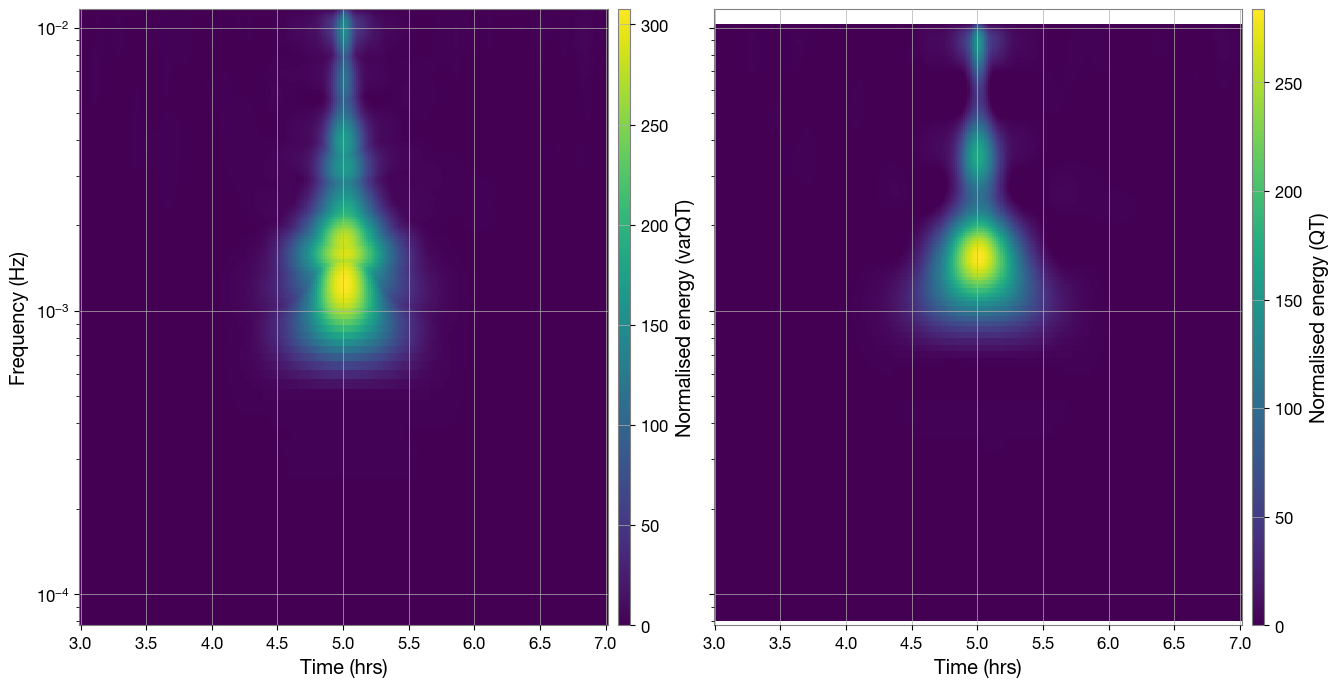

In [68]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(15,8))
#title = f'level={event["level"]:.2e}, beta={event["beta"]:.2e}, inj_point={event["inj_point"]}'
#fig.suptitle(title, fontsize=16)

axes[0].pcolormesh(t_arr/3600, f_arr, varQT, cmap='viridis')
axes[1].pcolormesh(t_arr2/3600, f_arr2, QT, cmap='viridis')
axes[0].set_xlabel('Time (hrs)')
axes[1].set_xlabel('Time (hrs)')
axes[0].set_ylabel('Frequency (Hz)')
axes[0].set_yscale('log')
axes[1].set_yscale('log')
axes[0].colorbar(label='Normalised energy (varQT)')
axes[1].colorbar(label='Normalised energy (QT)')
plt.show()